In [1]:
import sys, os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import pandas as pd
import numpy as np

import re

# Data de referencia fixa 

DATA_REF = pd.Timestamp("2026-05-01")

PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "src").exists())
sys.path.insert(0, str(PROJECT_ROOT))

from src import db

In [2]:
# Garantir que o src seja importável
PROJECT_ROOT = Path.cwd().resolve().parent

sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
#conferir o seu diretório de trabalho atual
os.getcwd()


'g:\\Meu Drive\\central_eto\\notebooks'

In [4]:
# Testando o ambiente, estamos mesmo usando o python do ambiente virtual?
sys.executable

'g:\\Meu Drive\\central_eto\\.venv\\Scripts\\python.exe'

In [5]:
db.test_connection()

(1,)

## Data Pofiling 
- Janela temporal? min e max -> definicao janela 
- Volume pedidos?
- Quantidade de clientes?

In [6]:
# ler arquivo
sql_text = Path("../queries/profiling_pedidos.sql").read_text()

# separar queries pelo marcador
queries = re.split(r"-- QUERIE:", sql_text)[1:]

# executar
results = {}

for q in queries:
    name, sql = q.strip().split("\n", 1)
    results[name.strip()] = db.get_data(sql)


g:\Meu Drive\central_eto\src\db.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, cn, params=params)


## Informações gerais

In [7]:
results["VOLUME POR ANO"]

,ANO,QTD
0,2007,40
1,2008,7360
2,2009,12109
3,2010,16648
4,2011,16299
5,2012,5558
6,2013,1
7,2018,8
8,2021,47191
9,2022,66612


In [8]:
results["CLIENTES DESDE 2023"]

,clientes
0,765


In [9]:
results["DATA MIN MAX"]

,DATA_MIN,DATA_MAX,QTD
0,2007-03-29,2026-06-02,535660


In [10]:
sql = Path("../queries/base_pedidos.sql").read_text()
df_base = db.get_data(sql)

df_base.head()


g:\Meu Drive\central_eto\src\db.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, cn, params=params)


,CLIENTE,SERVICO,SETOR,DATA_ENTRADA,VL_SERVICO,NRO_PED
0,903,SERVIÇO DE PROCESSAMENTO E ESTERILIZAÇÃO,CME,2024-07-06,0.00,0119925
1,37,CABO PARA MOTOR,GUSTAVO AQUINO,2021-05-03,24.25,25026
2,37,BISTURI ELÉTRICO (CABO+CANETA+PONTA),GUSTAVO AQUINO,2021-05-03,0.00,25026
3,37,PINÇA BIPOLAR,GUSTAVO AQUINO,2021-05-03,25.84,25026
4,2,CURETA,SME,2021-05-03,7.21,52


In [11]:
df_base.info()


<class 'pandas.DataFrame'>
RangeIndex: 535660 entries, 0 to 535659
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   CLIENTE       535660 non-null  int64         
 1   SERVICO       535660 non-null  str           
 2   SETOR         535660 non-null  str           
 3   DATA_ENTRADA  535660 non-null  datetime64[us]
 4   VL_SERVICO    535660 non-null  float64       
 5   NRO_PED       535660 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 41.2 MB


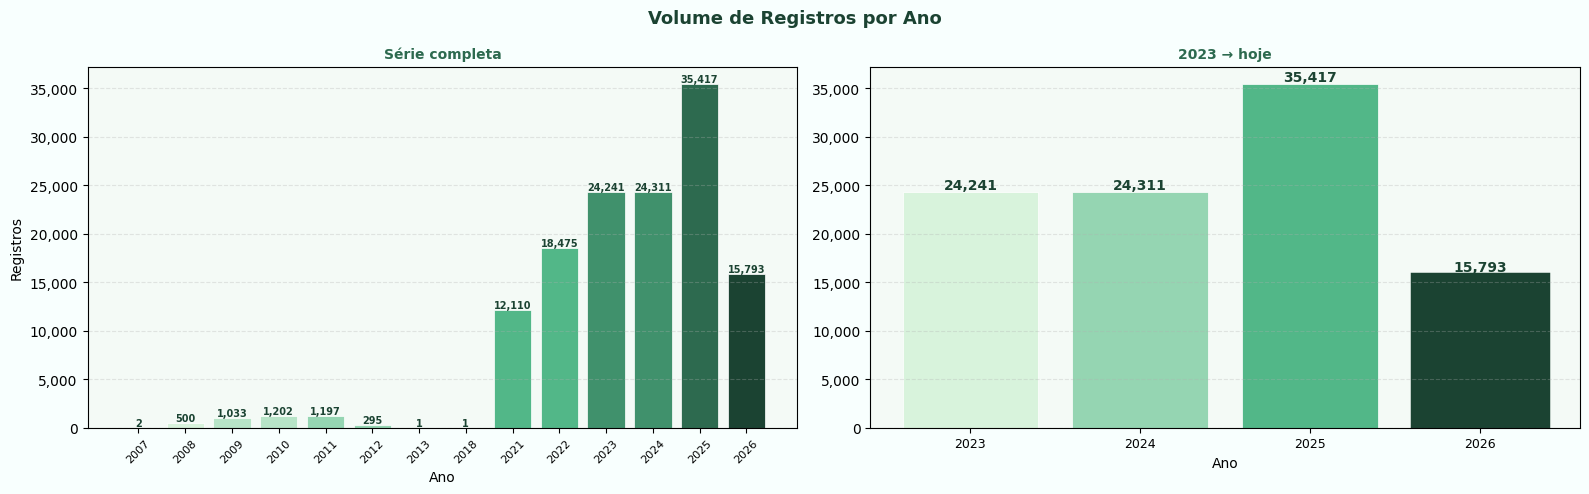

In [12]:
# ── Volume por ano derivado de df_base ──────────────────────────────────────
vol_ano = (
    df_base
    .groupby(df_base["DATA_ENTRADA"].dt.year)["NRO_PED"]
    .nunique()
    .reset_index(name="QTD_PEDIDOS")
    .rename(columns={"DATA_ENTRADA": "ANO"})
)

VERDE = ["#d8f3dc", "#b7e4c7", "#95d5b2", "#74c69d", "#52b788", "#40916c", "#2d6a4f", "#1b4332"]

def _verde_seq(n):
    idx = np.linspace(0, len(VERDE) - 1, n).astype(int)
    return [VERDE[i] for i in idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), facecolor="#f8fffe")
fig.suptitle("Volume de Registros por Ano", fontsize=13, fontweight="bold", color="#1b4332")

# ── Painel esquerdo: série completa ─────────────────────────────────────────
bars1 = ax1.bar(
    vol_ano["ANO"].astype(str), vol_ano["QTD_PEDIDOS"],
    color=_verde_seq(len(vol_ano)), edgecolor="white", linewidth=0.5
)
ax1.set_title("Série completa", fontsize=10, fontweight="bold", color="#2d6a4f")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Registros")
ax1.set_facecolor("#f4faf6")
ax1.grid(axis="y", alpha=0.3, linestyle="--")
ax1.tick_params(axis="x", rotation=45, labelsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar in bars1:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, h, f"{h:,.0f}",
        ha="center", va="bottom", fontsize=7, color="#1b4332", fontweight="bold"
    )

# ── Painel direito: 2023 → hoje ──────────────────────────────────────────────
vol_rec = vol_ano[vol_ano["ANO"] >= 2023].copy()
ano_atual = pd.Timestamp.now().year
bars2 = ax2.bar(
    vol_rec["ANO"].astype(str), vol_rec["QTD_PEDIDOS"],
    color=_verde_seq(len(vol_rec)), edgecolor="white", linewidth=0.5
)
ax2.set_title("2023 → hoje", fontsize=10, fontweight="bold", color="#2d6a4f")
ax2.set_xlabel("Ano")
ax2.set_facecolor("#f4faf6")
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax2.tick_params(axis="x", rotation=0, labelsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar, (_, row) in zip(bars2, vol_rec.iterrows()):
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2, h, f"{h:,.0f}",
        ha="center", va="bottom", fontsize=10, color="#1b4332", fontweight="bold"
    )
    if row["ANO"] == ano_atual:
        bar.set_edgecolor("#1b4332")
        bar.set_linewidth(2.5)

plt.tight_layout()
plt.show()

## Limpeza e Parsing

In [13]:
#Converter coluna de data e extrair ano-mês - maior eficiencia pra manipulação futura
df_base["DATA_ENTRADA"] = pd.to_datetime(df_base["DATA_ENTRADA"], errors="coerce")
df_base["ANO_MES"] = df_base["DATA_ENTRADA"].dt.to_period("M")
df_base.head()

,CLIENTE,SERVICO,SETOR,DATA_ENTRADA,VL_SERVICO,NRO_PED,ANO_MES
0,903,SERVIÇO DE PROCESSAMENTO E ESTERILIZAÇÃO,CME,2024-07-06,0.00,0119925,2024-07
1,37,CABO PARA MOTOR,GUSTAVO AQUINO,2021-05-03,24.25,25026,2021-05
2,37,BISTURI ELÉTRICO (CABO+CANETA+PONTA),GUSTAVO AQUINO,2021-05-03,0.00,25026,2021-05
3,37,PINÇA BIPOLAR,GUSTAVO AQUINO,2021-05-03,25.84,25026,2021-05
4,2,CURETA,SME,2021-05-03,7.21,52,2021-05


In [14]:
df_base.shape

(535660, 7)

## Check de sanidade - qualidade dos dados

In [15]:
sys.path.append("..")   
from src.sanity_check import sanity_check

sanity_check(
    df_base,
    value_col="VL_SERVICO",
    date_col="DATA_ENTRADA",    
    id_cols=["CLIENTE", "NRO_PED"]  )  

Shape: (535660, 7)

Missing:
CLIENTE         0
SERVICO         0
SETOR           0
DATA_ENTRADA    0
VL_SERVICO      0
NRO_PED         0
ANO_MES         0
dtype: int64

Duplicados:
21940

Negativos em VL_SERVICO :
  VL_SERVICO: 49

Datas: 2007-03-29 00:00:00 2026-06-02 00:00:00

Duplicados por chave:
401082


## Verificar conforme sanity check

In [16]:
# Ver as duplicatas reais (todas as colunas iguais)
duplicados = df_base[df_base.duplicated(keep=False)].sort_values(["NRO_PED", "SERVICO"])
print(f"Linhas envolvidas: {len(duplicados)}")
duplicados.head(20)


Linhas envolvidas: 37442


,CLIENTE,SERVICO,SETOR,DATA_ENTRADA,VL_SERVICO,NRO_PED,ANO_MES
441306,318,KIT CIRURGICO (PEQUENA CIRURGIA),PACHECO,2025-10-29,34.37,0002025,2025-10
441308,318,KIT CIRURGICO (PEQUENA CIRURGIA),PACHECO,2025-10-29,34.37,0002025,2025-10
446901,1433,CAIXA (31PÇS),CCI,2025-11-08,46.50,0002525,2025-11
446904,1433,CAIXA (31PÇS),CCI,2025-11-08,46.50,0002525,2025-11
446900,1433,CAIXA (56 PÇS),CCI,2025-11-08,99.12,0002525,2025-11
446906,1433,CAIXA (56 PÇS),CCI,2025-11-08,99.12,0002525,2025-11
79514,599,CABO DE FIBRA ÓPTICA,GERAL,2022-05-18,118.01,002287,2022-05
79515,599,CABO DE FIBRA ÓPTICA,GERAL,2022-05-18,118.01,002287,2022-05
78671,45,KIT CIRURGICO (PEQUENA CIRURGIA),CME,2022-05-13,44.63,002441,2022-05
78674,45,KIT CIRURGICO (PEQUENA CIRURGIA),CME,2022-05-13,44.63,002441,2022-05


Duplicatas esperadas: o sistema registra uma linha por unidade de item pedido.
Dois itens idênticos no mesmo pedido geram duas linhas iguais — comportamento correto do modelo de dados, não erro.

A agregação em make_cliente_mes usa nunique em NRO_PED, garantindo que pedidos não sejam inflados por essa granularidade.


In [17]:
df_base.loc[
    df_base["VL_SERVICO"] < 0,
    ["CLIENTE", "NRO_PED", "DATA_ENTRADA", "VL_SERVICO"]
]

,CLIENTE,NRO_PED,DATA_ENTRADA,VL_SERVICO
3167,10,23354,2021-05-15,-27.39
3773,40,25614,2021-05-18,-10.76
14966,5,11249,2021-07-10,-21.30
28790,15,26776,2021-09-14,-309.99
31955,74,17534,2021-09-29,-9.20
32180,104,22495,2021-09-30,-17.72
36752,3,16676,2021-10-21,-5.46
43797,29,5561,2021-11-23,-12.29
48734,63,12624,2021-12-13,-1.97
50573,226,7536,2021-12-21,-96.80


In [18]:
df_base["ANO_MES"] = df_base["DATA_ENTRADA"].dt.to_period("M")
df_base.info()

<class 'pandas.DataFrame'>
RangeIndex: 535660 entries, 0 to 535659
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   CLIENTE       535660 non-null  int64         
 1   SERVICO       535660 non-null  str           
 2   SETOR         535660 non-null  str           
 3   DATA_ENTRADA  535660 non-null  datetime64[us]
 4   VL_SERVICO    535660 non-null  float64       
 5   NRO_PED       535660 non-null  str           
 6   ANO_MES       535660 non-null  period[M]     
dtypes: datetime64[us](1), float64(1), int64(1), period[M](1), str(3)
memory usage: 45.3 MB


In [19]:
sys.path.append("..")

from src.features_EDA_pedidos import make_cliente_mes
from src.config import INICIO

## Feature Engineering — Criação de Features Cliente-Mês

A célula abaixo inicia a **fase de feature engineering** do pipeline analítico. Estamos transformando a base transacional bruta em features estruturadas que capturam o comportamento de compra de cada cliente ao longo do tempo.

### O que estamos construindo

A função `make_cliente_mes` agrega a base de pedidos no nível **cliente × mês**, granularidade necessária para modelar padrões de recompra, sazonalidade e risco de churn. Cada linha resultante representa um cliente em um mês específico, com suas métricas de atividade consolidadas.

### Features geradas

| Feature | Descrição |
|---|---|
| `total_pedidos` | Pedidos únicos no mês (`nunique` de `NRO_PED`) |
| `total_valor` | Faturamento mensal (negativos tratados via `neg_policy`) |
| `qtd_itens` | Total de linhas/itens do mês |
| `ticket_medio` | Valor médio por pedido (`total_valor / total_pedidos`) |
| `itens_por_pedido` | Densidade de itens por pedido |

### Parâmetros de controle

- **`inicio="2023-01-01"`** — janela temporal alinhada ao período de maior qualidade de dados (743 clientes ativos desde 2023).
- **`neg_policy="clip0"`** — valores negativos são zerados antes da agregação, evitando distorção no faturamento sem descartar o registro histórico.

> Esta tabela é a **base de todas as análises subsequentes** — segmentação, sazonalidade e modelagem de churn.

In [20]:
cliente_mes = make_cliente_mes(df_base, inicio=INICIO, neg_policy="clip0")
cliente_mes.head()

,CLIENTE,ANO_MES,total_pedidos,total_valor,qtd_itens,ticket_medio,itens_por_pedido,categoria_pedido
0,1,2023-01,117,31032.50,538,265.235043,4.598291,premium
1,1,2023-02,72,12877.19,307,178.849861,4.263889,premium
2,1,2023-03,82,18778.31,346,229.003780,4.219512,premium
3,1,2023-04,87,18732.18,383,215.312414,4.402299,premium
4,1,2023-05,84,16106.26,328,191.741190,3.904762,premium


## Validacao de agregacao


In [21]:
sys.path.append("..")

from src.sanity_check import sanity_check

sanity_check(
    cliente_mes,
    value_col="total_valor",
    date_col="ANO_MES",
    id_cols=["CLIENTE", "ANO_MES"]  # chave real: um cliente num mês
)

Shape: (9980, 8)

Missing:
CLIENTE             0
ANO_MES             0
total_pedidos       0
total_valor         0
qtd_itens           0
ticket_medio        0
itens_por_pedido    0
categoria_pedido    0
dtype: int64

Duplicados:
0

Negativos em total_valor :
  total_valor: 0

Datas: 2023-01 2026-06

Duplicados por chave:
0


## EDA Analitica 
- Descricao do **comportamento** de cada cliente por mes.

## Pedidos

In [22]:
## RELACOES CLIENTE-MES
cliente_mes["total_pedidos"].describe()

count    9980.000000
mean        9.996192
std        61.072231
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max      1605.000000
Name: total_pedidos, dtype: float64

Distribuiçao extremamente assimetrica

9824 pedidos, media de 9 pedidos por mes, mas desvio padrao imenso de quase 60. 

Heterogeneidade de pedidos por cliente - ate 25% sao pedido por mes. 

Valores max e minimos muito discrepantes 

**Necessidade de segmentaçao em conformidade com os quartis**



In [23]:
# A categoria de pedido já foi calculada internamente em make_cliente_mes().
# Aqui apenas validamos a distribuição resultante.
cliente_mes["categoria_pedido"].value_counts(normalize=True)


categoria_pedido
baixo      0.575150
medio      0.199499
alto       0.170240
premium    0.055110
Name: proportion, dtype: float64

In [24]:
cliente_mes.groupby("categoria_pedido")["total_pedidos"].describe()

,count,mean,std,min,25%,50%,75%,max
categoria_pedido,,,,,,,,
alto,1699.0,9.978811,3.634934,6.0,7.0,9.0,12.0,19.0
baixo,5740.0,1.309756,0.462433,1.0,1.0,1.0,2.0,2.0
medio,1991.0,3.758915,0.774038,3.0,3.0,4.0,4.0,5.0
premium,550.0,123.283636,232.299441,20.0,27.0,43.0,106.5,1605.0


Nota-se que mesmo apos a classificacao em tres categorias, os pedidos G ainda sao bem irregulares, variando de 6 a 1650, sendo valores extremos como este claramente outleiers. Dessa maneira criaremos uma nova categoria com o quartil 75% da categoria alta. Que sera pedido Premium, com mais de 19 pedidos por mes

In [25]:
def classificar_volume_mes(x):
    if x <= 2:
        return "baixo"
    elif x <= 5:
        return "medio"
    elif x <= 19:
        return "alto"
    else:
        return "premium"

cliente_mes["categoria_pedido"] = cliente_mes["total_pedidos"].apply(classificar_volume_mes)
cliente_mes["categoria_pedido"].value_counts(normalize=True)


categoria_pedido
baixo      0.575150
medio      0.199499
alto       0.170240
premium    0.055110
Name: proportion, dtype: float64

C:\Users\carva\AppData\Local\Temp\ipykernel_28736\609859485.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=categorias, patch_artist=True,


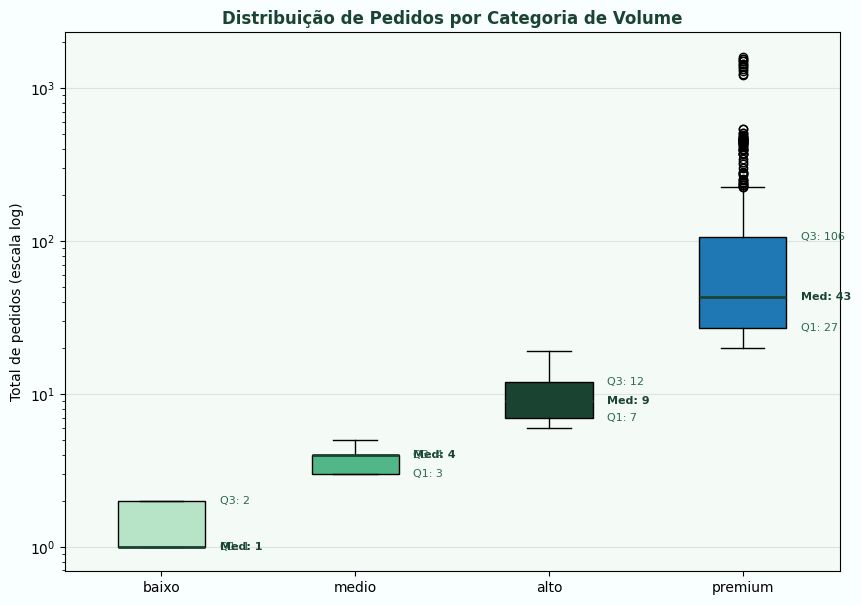

In [26]:
fig, ax = plt.subplots(figsize=(10, 7), facecolor="#f8fffe")

categorias = ["baixo", "medio", "alto", "premium"]
dados = [cliente_mes[cliente_mes["categoria_pedido"] == c]["total_pedidos"] for c in categorias]

bp = ax.boxplot(dados, labels=categorias, patch_artist=True, 
                medianprops=dict(color="#1b4332", linewidth=2))

cores = ["#b7e4c7", "#52b788", "#1b4332"]
for patch, cor in zip(bp["boxes"], cores):
    patch.set_facecolor(cor)

ax.set_yscale("log")
ax.set_title("Distribuição de Pedidos por Categoria de Volume", 
             fontweight="bold", color="#1b4332")
ax.set_ylabel("Total de pedidos (escala log)")
ax.set_facecolor("#f4faf6")
ax.grid(axis="y", alpha=0.3)

for i, dado in enumerate(dados, start=1):
    q1  = dado.quantile(0.25)
    med = dado.quantile(0.50)
    q3  = dado.quantile(0.75)
    ax.text(i + 0.3, q1,  f"Q1: {q1:.0f}",  va="center", fontsize=8, color="#2d6a4f")
    ax.text(i + 0.3, med, f"Med: {med:.0f}", va="center", fontsize=8, color="#1b4332", fontweight="bold")
    ax.text(i + 0.3, q3,  f"Q3: {q3:.0f}",  va="center", fontsize=8, color="#2d6a4f")


plt.show()

In [27]:
acima_q3 = cliente_mes[cliente_mes["categoria_pedido"] == "premium"]["total_pedidos"]
print((acima_q3 > 108).sum(), "registros acima de 108")
print((acima_q3 > 108).sum() / len(acima_q3) * 100, "% do premium")


136 registros acima de 108
24.727272727272727 % do premium


In [28]:
clientes_acima = cliente_mes[
    (cliente_mes["categoria_pedido"] == "premium") & 
    (cliente_mes["total_pedidos"] > 108)
]["CLIENTE"].nunique()

print(clientes_acima, "clientes distintos acima de 108 pedidos/mês")


7 clientes distintos acima de 108 pedidos/mês


25% dos registros premium têm mais de 108 pedidos/mês, mas representam apenas 7 clientes distintos — menos de 1% da base.

Não justifica nova categoria — serão tratados como casos extremos dentro do segmento premium.


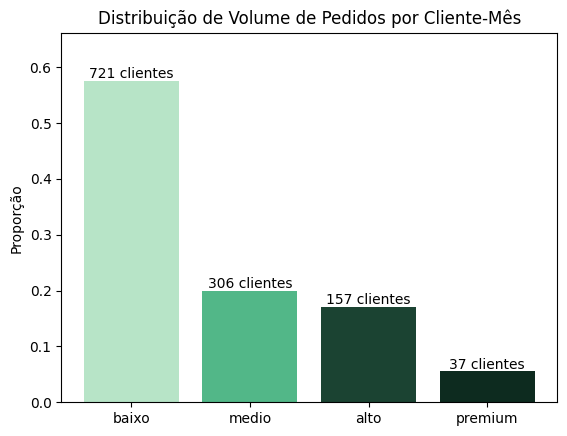

In [29]:
import matplotlib.pyplot as plt

ordem = ["baixo", "medio", "alto", "premium"]

dist = (
    cliente_mes["categoria_pedido"]
    .value_counts(normalize=True)
    .reindex(ordem)
)

# clientes distintos por categoria
clientes_por_cat = (
    cliente_mes.groupby("categoria_pedido")["CLIENTE"]
    .nunique()
    .reindex(ordem)
)

plt.figure()

bars = plt.bar(
    dist.index,
    dist.values,
    color=["#b7e4c7", "#52b788", "#1b4332", "#0d2b1f"]
)

plt.ylabel("Proporção")
plt.title("Distribuição de Volume de Pedidos por Cliente-Mês")

for bar, cat in zip(bars, ordem):
    height = bar.get_height()
    n_clientes = clientes_por_cat[cat]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{n_clientes} clientes",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(dist.values) * 1.15)
plt.xticks(rotation=0)
plt.show()


## Frequencia de compra

Diferenciacao da frequencia de compra de cada categoria.

In [30]:
try:
    if hasattr(cliente_mes["ANO_MES"], "dt"):
        cliente_mes["ANO_MES"] = cliente_mes["ANO_MES"].dt.to_timestamp()
    else:
        cliente_mes["ANO_MES"] = pd.to_datetime(cliente_mes["ANO_MES"])
except Exception:
    cliente_mes["ANO_MES"] = pd.to_datetime(cliente_mes["ANO_MES"])

def diff_meses(a, b):
    return (a.dt.year - b.dt.year) * 12 + (a.dt.month - b.dt.month)

mes_anterior = cliente_mes.groupby("CLIENTE")["ANO_MES"].shift(1)

cliente_mes["meses_desde_ultimo"] = diff_meses(cliente_mes["ANO_MES"], mes_anterior)
cliente_mes["meses_desde_ultimo"] = cliente_mes["meses_desde_ultimo"].fillna(0).astype(int)

display(cliente_mes.tail(5))

,CLIENTE,ANO_MES,total_pedidos,total_valor,qtd_itens,ticket_medio,itens_por_pedido,categoria_pedido,meses_desde_ultimo
9975,1667,2026-04-01,1,304.49,8,304.490000,8.000000,baixo,0
9976,1667,2026-05-01,3,248.17,13,82.723333,4.333333,medio,1
9977,1669,2026-05-01,1,52.96,3,52.960000,3.000000,baixo,0
9978,1672,2026-05-01,2,127.81,4,63.905000,2.000000,baixo,0
9979,1674,2026-05-01,3,885.42,12,295.140000,4.000000,medio,0


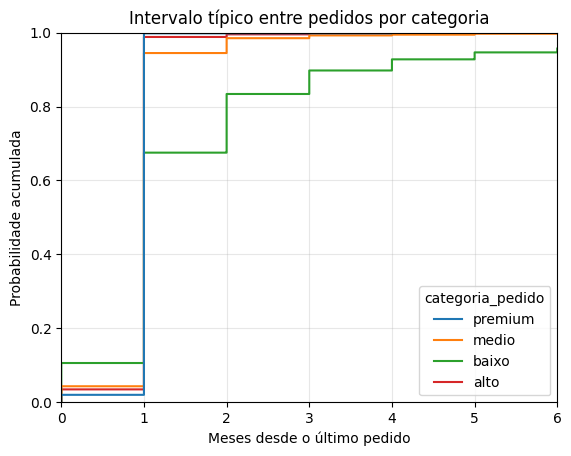

In [31]:
import seaborn as sns

sns.ecdfplot(
    data=cliente_mes,
    x="meses_desde_ultimo",
    hue="categoria_pedido"
)
plt.xlim(0, 6)
plt.title("Intervalo típico entre pedidos por categoria")
plt.xlabel("Meses desde o último pedido")
plt.ylabel("Probabilidade acumulada")
plt.grid(True, alpha=0.3)
plt.show()

## Definicao de Threshold de Churn por Categoria

A analise ECDF do intervalo entre pedidos () mostrou o tempo tipico de recompra por segmento. Com base nos quantis observados, foram definidos os seguintes thresholds:

| Categoria | Threshold | Justificativa |
|-----------|-----------|---------------|
| premium | 2 meses | Compra praticamente toda semana — 2 meses e ruptura clara |
| alto | 2 meses | Compra mensalmente — qualquer ausencia alem de 1 mes e sinal de alerta |
| medio | 3 meses | Frequencia proxima do alto, com pequena tolerancia |
| baixo | 6 meses | Naturalmente espacado — punir antes de 6 meses seria precipitado |

> Um cliente e marcado como RED_FLAG quando  da sua categoria.

## Fidelidade


In [32]:
# Agrupando para entender o padrao de cada cliente

# ultimo mes de cada cliente para capturar tendencia
ultimo_mes_cliente = (
    cliente_mes.sort_values('ANO_MES')
    .groupby('CLIENTE')
    .last()
    .reset_index()[['CLIENTE', 'total_valor', 'ticket_medio']]
    .rename(columns={'total_valor': 'valor_ultimo_mes', 'ticket_medio': 'ticket_medio_ultimo_mes'})
)

cliente_fidelidade = cliente_mes.groupby('CLIENTE').agg(
    total_meses_ativos=('ANO_MES',           'count'),
    intervalo_medio=('meses_desde_ultimo',   lambda x: x[x > 0].mean()),
    max_intervalo=('meses_desde_ultimo',     'max'),
    ultimo_pedido=('ANO_MES',               'max'),
    categoria_cliente=('categoria_pedido',   lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    total_valor_historico=('total_valor',    'sum'),
    ticket_medio_geral=('ticket_medio',     'mean'),
).reset_index()

# Garantir que ultimo_pedido seja Timestamp
cliente_fidelidade['ultimo_pedido'] = pd.to_datetime(cliente_fidelidade['ultimo_pedido'].astype(str))

# Recencia: ha quantos meses ele nao aparece
cliente_fidelidade['meses_sumido'] = (
    (DATA_REF.year  - cliente_fidelidade['ultimo_pedido'].dt.year)  * 12 +
    (DATA_REF.month - cliente_fidelidade['ultimo_pedido'].dt.month)
)

# Tendencia: valor e ticket do ultimo mes
cliente_fidelidade = cliente_fidelidade.merge(ultimo_mes_cliente, on='CLIENTE', how='left')

cliente_fidelidade.head(5)


,CLIENTE,total_meses_ativos,intervalo_medio,max_intervalo,ultimo_pedido,categoria_cliente,total_valor_historico,ticket_medio_geral,meses_sumido,valor_ultimo_mes,ticket_medio_ultimo_mes
0,1,42,1.0,1,2026-06-01,premium,595266.84,234.592284,-1,926.49,231.622500
1,3,41,1.0,1,2026-05-01,premium,2131317.65,495.215316,0,65520.81,642.360882
2,4,42,1.0,1,2026-06-01,premium,584020.78,129.241266,-1,140.75,70.375000
3,5,22,1.0,1,2024-10-01,premium,142715.92,253.604980,19,385.90,128.633333
4,7,4,1.0,1,2023-04-01,alto,16261.87,201.087907,37,3917.21,326.434167


Com essas informacoes consigo enter a recencia de cada cliente, o tempo de da ultima compra ate hoje e a cadencia historica atraves do intervalo medio.

A ideia e criar uma variavel que indique uma "red_flag" para a saida de um cliente. Como por exemplo. 

*Se um cliente ficar sem comprar por mais tempo que o intervalo_medio e sinal de alerta?*

Para que eu crie essa variavel e necessario que eu valide essa inferencia, estatisticamente. O que pode ser descobrir pela analise de distribuicao com quanto tempo uma categoria de cliente, volta a comprar.

In [33]:
# Threshold de churn por categoria (baseado na cadencia historica de recompra)
threshold_churn = {'baixo': 6, 'medio': 3, 'alto': 2, 'premium': 2}
cliente_fidelidade['threshold_churn'] = cliente_fidelidade['categoria_cliente'].map(threshold_churn)


Aqui vimos que a feature *intervalo_medio* tem limitacoes. se houver apenas uma observacao, e pouco confiavel estatisticamente.

Se nao tem intervalo medio, 'e porque so compraram um mes. 

Clientes com intervalos acim de 3 meses sao mais confiaveis estatisticamente.

Dessa forma vamos acrescentar uma coluna a tabela de cliente fidelidade, n_intervalos. 


In [34]:
# n_intervalos: quantos intervalos reais cada cliente tem (confiabilidade do intervalo_medio)
n_intervalos = (
    cliente_mes.groupby('CLIENTE')['meses_desde_ultimo']
    .apply(lambda x: (x > 0).sum())
    .rename('n_intervalos')
    .reset_index()
)
cliente_fidelidade = cliente_fidelidade.merge(n_intervalos, on='CLIENTE', how='left')

# RED_FLAG: sumido alem do threshold E com historico suficiente para confiar
historico_confiavel = cliente_fidelidade['n_intervalos'] >= 3

cliente_fidelidade['RED_FLAG'] = (
    (cliente_fidelidade['meses_sumido'] > cliente_fidelidade['threshold_churn'])
    & historico_confiavel
)

# True = historico confiavel (n >= 3 intervalos)
cliente_fidelidade['historico_confiavel'] = historico_confiavel

print('RED_FLAG por categoria:')
print(cliente_fidelidade.groupby('categoria_cliente')['RED_FLAG'].mean().map('{:.1%}'.format))
print()
print(f"Clientes com historico confiavel  (n>=3): {historico_confiavel.sum()}")
print(f"Clientes com historico insuficiente:      {(~historico_confiavel).sum()}")

RED_FLAG por categoria:
categoria_cliente
alto       28.8%
baixo      16.3%
medio      19.0%
premium    31.2%
Name: RED_FLAG, dtype: str

Clientes com historico confiavel  (n>=3): 483
Clientes com historico insuficiente:      282


In [35]:
# Não deve existir nenhum RED_FLAG=True com n_intervalos < 3
assert cliente_fidelidade[
    (cliente_fidelidade["RED_FLAG"] == True) & 
    (cliente_fidelidade["n_intervalos"] < 3)
].empty, "Tem RED_FLAG com histórico insuficiente — algo está errado"

print("✓ Verificação passou")

✓ Verificação passou


In [36]:
display(cliente_fidelidade.head(20))

,CLIENTE,total_meses_ativos,intervalo_medio,max_intervalo,ultimo_pedido,categoria_cliente,total_valor_historico,ticket_medio_geral,meses_sumido,valor_ultimo_mes,ticket_medio_ultimo_mes,threshold_churn,n_intervalos,RED_FLAG,historico_confiavel
0,1,42,1.000000,1,2026-06-01,premium,595266.84,234.592284,-1,926.49,231.622500,2,41,False,True
1,3,41,1.000000,1,2026-05-01,premium,2131317.65,495.215316,0,65520.81,642.360882,2,40,False,True
2,4,42,1.000000,1,2026-06-01,premium,584020.78,129.241266,-1,140.75,70.375000,2,41,False,True
3,5,22,1.000000,1,2024-10-01,premium,142715.92,253.604980,19,385.90,128.633333,2,21,True,True
4,7,4,1.000000,1,2023-04-01,alto,16261.87,201.087907,37,3917.21,326.434167,2,3,True,True
5,9,7,6.666667,29,2026-05-01,baixo,3637.61,322.479048,0,428.26,107.065000,6,6,False,True
6,10,31,1.000000,1,2026-05-01,alto,68227.86,201.545331,0,2030.86,406.172000,2,30,False,True
7,12,41,1.000000,1,2026-05-01,alto,158151.15,198.400332,0,5762.36,360.147500,2,40,False,True
8,15,37,1.000000,1,2026-01-01,alto,835701.46,2203.507673,4,13601.60,3400.400000,2,36,True,True
9,21,7,1.000000,1,2023-07-01,premium,80694.33,262.917081,34,6473.57,239.761852,2,6,True,True


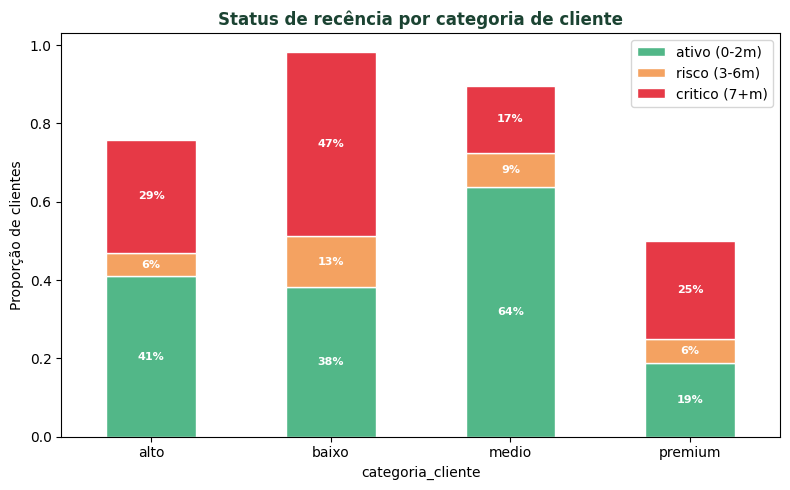

In [37]:
faixas = {
    "ativo (0-2m)":   (0, 2),
    "risco (3-6m)":   (3, 6),
    "critico (7+m)":  (7, 999),
}

cores_faixas = ["#52b788", "#f4a261", "#e63946"]

tabela = {}
for label, (lo, hi) in faixas.items():
    tabela[label] = cliente_fidelidade.groupby("categoria_cliente").apply(
        lambda x: ((x["meses_sumido"] >= lo) & (x["meses_sumido"] <= hi)).mean()
    )

df_plot = pd.DataFrame(tabela)

ax = df_plot.plot(kind="bar", stacked=True, color=cores_faixas, figsize=(8, 5), edgecolor="white")
plt.title("Status de recência por categoria de cliente", fontweight="bold", color="#1b4332")
plt.ylabel("Proporção de clientes")
plt.xticks(rotation=0)
plt.legend(loc="upper right")

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.0f%%", label_type="center",
                 fontsize=8, color="white", fontweight="bold",
                 labels=[f"{v*100:.0f}%" for v in bars.datavalues])

plt.tight_layout()
plt.show()


In [38]:
(
    cliente_fidelidade[cliente_fidelidade["RED_FLAG"] == True]
    [["CLIENTE", "categoria_cliente", "meses_sumido", "threshold_churn", 
      "ultimo_pedido", "total_valor_historico"]]
    .assign(meses_alem_threshold=lambda df: df["meses_sumido"] - df["threshold_churn"])
    .query("meses_alem_threshold <= 2")  # ate 2 meses alem do threshold
    .sort_values("meses_alem_threshold")
    .head(10)
)


,CLIENTE,categoria_cliente,meses_sumido,threshold_churn,ultimo_pedido,total_valor_historico,meses_alem_threshold
50,87,baixo,7,6,2025-10-01,10927.18,1
44,81,baixo,7,6,2025-10-01,15078.09,1
84,129,baixo,7,6,2025-10-01,9275.88,1
63,102,baixo,7,6,2025-10-01,4310.08,1
89,134,baixo,7,6,2025-10-01,237.71,1
122,174,medio,4,3,2026-01-01,36253.89,1
204,309,baixo,7,6,2025-10-01,465.77,1
171,256,baixo,7,6,2025-10-01,48988.54,1
217,339,baixo,7,6,2025-10-01,7107.49,1
262,441,baixo,7,6,2025-10-01,160.57,1


Cruzar os dados de cliente fidelidade com tem red flag true com o status. 

## Dashboard por Cliente

Relatório visual consolidado de um cliente individual — sazonalidade, evolução mensal e acumulados anuais.  
Troque `CLIENTE_ID` na célula abaixo para mudar o cliente.

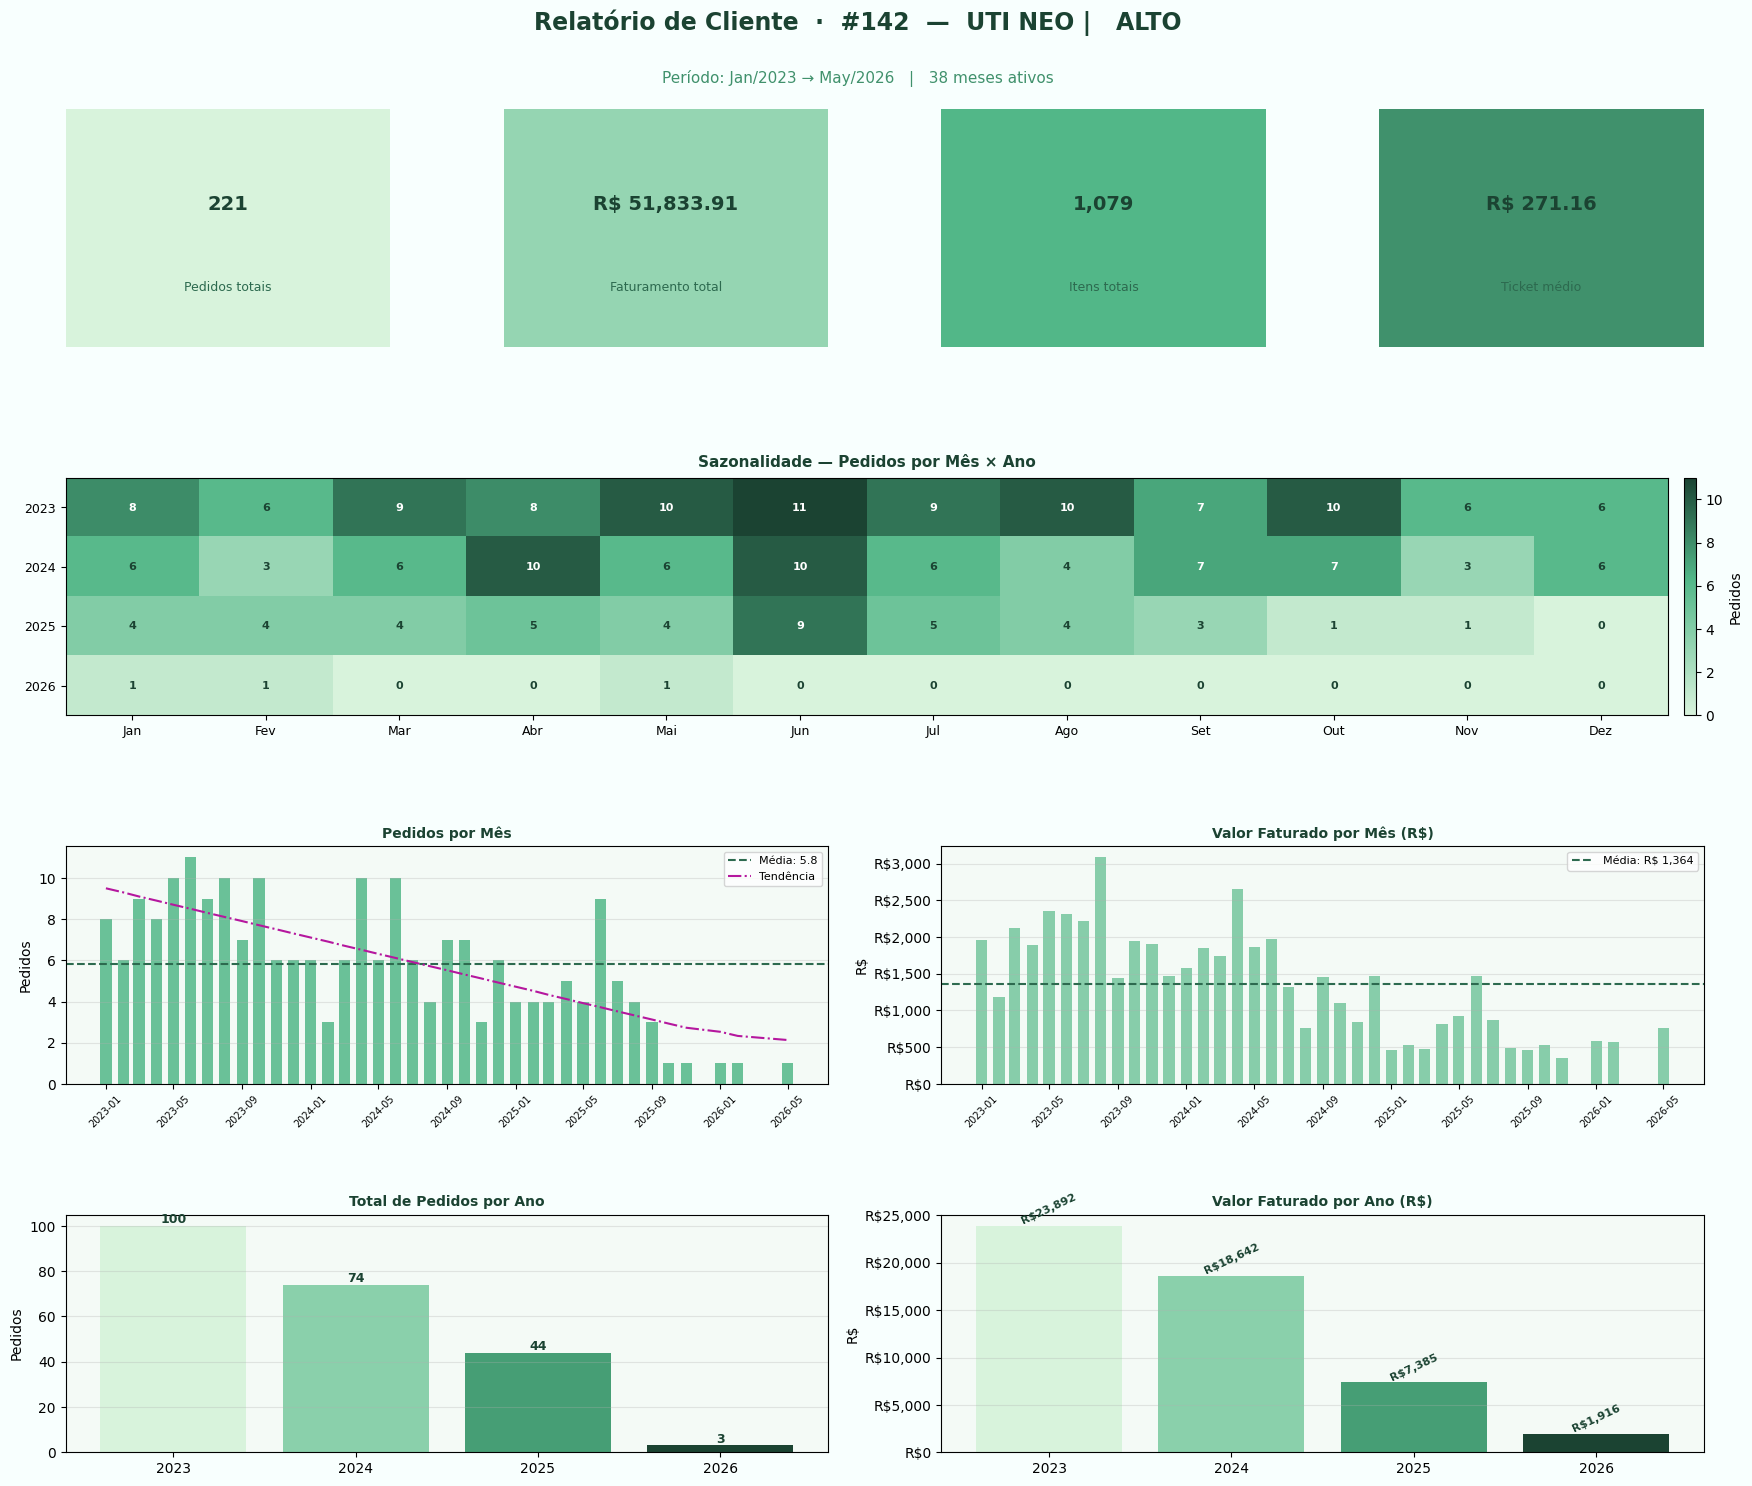

In [39]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO  —  troque apenas esta linha para mudar o cliente
CLIENTE_ID = 142
# ══════════════════════════════════════════════════════════════════════════════

VERDE = ["#d8f3dc", "#b7e4c7", "#95d5b2", "#74c69d", "#52b788", "#40916c", "#2d6a4f", "#1b4332"]
cmap_v = LinearSegmentedColormap.from_list("verde", VERDE)

def _grad(n):
    return [cmap_v(i / max(n - 1, 1)) for i in range(n)]

# ── filtrar e preparar ────────────────────────────────────────────────────────
cm = cliente_mes[cliente_mes["CLIENTE"] == CLIENTE_ID].copy()
cm["ANO_MES"] = pd.to_datetime(cm["ANO_MES"].astype(str))
cm = cm.sort_values("ANO_MES")
cm["ANO"] = cm["ANO_MES"].dt.year
cm["MES"] = cm["ANO_MES"].dt.month

if cm.empty:
    raise ValueError(f"Cliente {CLIENTE_ID} não encontrado em cliente_mes.")

# ── KPIs ──────────────────────────────────────────────────────────────────────
total_pedidos = int(cm["total_pedidos"].sum())
total_valor   = cm["total_valor"].sum()
total_itens   = int(cm["qtd_itens"].sum())
ticket_medio  = cm["ticket_medio"].mean()
primeiro_mes  = cm["ANO_MES"].min().strftime("%b/%Y")
ultimo_mes    = cm["ANO_MES"].max().strftime("%b/%Y")
n_meses       = len(cm)
setor_s       = df_base.loc[df_base["CLIENTE"] == CLIENTE_ID, "SETOR"]
setor         = setor_s.iloc[0] if not setor_s.empty else "—"
cat_s         = cliente_fidelidade.loc[cliente_fidelidade["CLIENTE"] == CLIENTE_ID, "categoria_cliente"]
categoria     = cat_s.iloc[0].upper() if not cat_s.empty else "—"

por_ano = cm.groupby("ANO").agg(
    pedidos=("total_pedidos", "sum"),
    valor=("total_valor", "sum"),
).reset_index()

# ── heatmap: pivot ANO × MES ──────────────────────────────────────────────────
MESES = {1:"Jan",2:"Fev",3:"Mar",4:"Abr",5:"Mai",6:"Jun",
         7:"Jul",8:"Ago",9:"Set",10:"Out",11:"Nov",12:"Dez"}
heat = cm.pivot_table(index="ANO", columns="MES", values="total_pedidos",
                      aggfunc="sum", fill_value=0)
for m in MESES:
    if m not in heat.columns:
        heat[m] = 0
heat = heat[list(MESES.keys())]
heat.rename(columns=MESES, inplace=True)

# ── figura ────────────────────────────────────────────────────────────────────
n_anos = heat.shape[0]
altura = max(15, 11 + n_anos * 1.2)
fig = plt.figure(figsize=(18, altura), facecolor="#f8fffe")
gs = gridspec.GridSpec(4, 4, figure=fig,
                       hspace=0.55, wspace=0.35,
                       top=0.90, bottom=0.05, left=0.06, right=0.97)

fig.text(0.5, 0.95,
         f"Relatório de Cliente  ·  #{CLIENTE_ID}  —  {setor} |   {categoria}",
         ha="center", fontsize=17, fontweight="bold", color="#1b4332")
fig.text(0.5, 0.917,
         f"Período: {primeiro_mes} → {ultimo_mes}   |   {n_meses} meses ativos",
         ha="center", fontsize=11, color="#40916c")

# ── KPI CARDS ─────────────────────────────────────────────────────────────────
kpis = [
    ("Pedidos totais",    f"{total_pedidos:,}",        VERDE[0]),
    ("Faturamento total", f"R$ {total_valor:,.2f}",    VERDE[2]),
    ("Itens totais",      f"{total_itens:,}",           VERDE[4]),
    ("Ticket médio",      f"R$ {ticket_medio:,.2f}",   VERDE[5]),
]
for i, (label, valor, cor) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(cor)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.text(0.5, 0.60, valor, ha="center", va="center",
            fontsize=14, fontweight="bold", color="#1b4332",
            transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha="center", va="center",
            fontsize=9, color="#2d6a4f", transform=ax.transAxes)

# ── HEATMAP SAZONALIDADE ──────────────────────────────────────────────────────
ax_h = fig.add_subplot(gs[1, :])
vmax = heat.values.max() or 1
im = ax_h.imshow(heat.values, aspect="auto", cmap=cmap_v, vmin=0, vmax=vmax)
ax_h.set_xticks(range(12))
ax_h.set_xticklabels(heat.columns, fontsize=9)
ax_h.set_yticks(range(len(heat)))
ax_h.set_yticklabels(heat.index, fontsize=9)
ax_h.set_title("Sazonalidade — Pedidos por Mês × Ano",
               fontsize=11, fontweight="bold", color="#1b4332", pad=8)
for r in range(len(heat)):
    for c in range(12):
        v = int(heat.values[r, c])
        tc = "white" if v > vmax * 0.55 else "#1b4332"
        ax_h.text(c, r, f"{v}", ha="center", va="center",
                  fontsize=8, color=tc, fontweight="bold")
plt.colorbar(im, ax=ax_h, orientation="vertical",
             fraction=0.012, pad=0.01, label="Pedidos")

# ── PEDIDOS MENSAIS ───────────────────────────────────────────────────────────
ax_pm = fig.add_subplot(gs[2, :2])
ax_pm.bar(cm["ANO_MES"], cm["total_pedidos"], color=VERDE[4], alpha=0.85, width=20)
med_p = cm["total_pedidos"].mean()
ax_pm.axhline(med_p, color=VERDE[6], ls="--", lw=1.5, label=f"Média: {med_p:.1f}")
z = np.polyfit(range(len(cm)), cm["total_pedidos"], 1)
ax_pm.plot(cm["ANO_MES"], np.polyval(z, range(len(cm))),
           color="#b5179e", lw=1.5, ls="-.", label="Tendência")
ax_pm.set_title("Pedidos por Mês", fontsize=10, fontweight="bold", color="#1b4332")
ax_pm.set_ylabel("Pedidos")
ax_pm.legend(fontsize=8)
ax_pm.tick_params(axis="x", rotation=45, labelsize=7)
ax_pm.set_facecolor("#f4faf6")
ax_pm.grid(axis="y", alpha=0.3)

# ── VALOR MENSAL ──────────────────────────────────────────────────────────────
ax_vm = fig.add_subplot(gs[2, 2:])
ax_vm.bar(cm["ANO_MES"], cm["total_valor"], color=VERDE[3], alpha=0.85, width=20)
med_v = cm["total_valor"].mean()
ax_vm.axhline(med_v, color=VERDE[6], ls="--", lw=1.5,
              label=f"Média: R$ {med_v:,.0f}")
ax_vm.set_title("Valor Faturado por Mês (R$)", fontsize=10, fontweight="bold", color="#1b4332")
ax_vm.set_ylabel("R$")
ax_vm.legend(fontsize=8)
ax_vm.tick_params(axis="x", rotation=45, labelsize=7)
ax_vm.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax_vm.set_facecolor("#f4faf6")
ax_vm.grid(axis="y", alpha=0.3)

# ── PEDIDOS POR ANO ───────────────────────────────────────────────────────────
ax_pa = fig.add_subplot(gs[3, :2])
cores_a = _grad(len(por_ano))
bp = ax_pa.bar(por_ano["ANO"].astype(str), por_ano["pedidos"], color=cores_a)
for bar, val in zip(bp, por_ano["pedidos"]):
    ax_pa.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
               f"{val:,}", ha="center", va="bottom",
               fontsize=9, fontweight="bold", color="#1b4332")
ax_pa.set_title("Total de Pedidos por Ano", fontsize=10, fontweight="bold", color="#1b4332")
ax_pa.set_ylabel("Pedidos")
ax_pa.set_facecolor("#f4faf6")
ax_pa.grid(axis="y", alpha=0.3)

# ── VALOR POR ANO ─────────────────────────────────────────────────────────────
ax_va = fig.add_subplot(gs[3, 2:])
bv = ax_va.bar(por_ano["ANO"].astype(str), por_ano["valor"], color=cores_a)
for bar, val in zip(bv, por_ano["valor"]):
    ax_va.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
               f"R${val:,.0f}", ha="center", va="bottom",
               fontsize=8, fontweight="bold", color="#1b4332", rotation=25)
ax_va.set_title("Valor Faturado por Ano (R$)", fontsize=10, fontweight="bold", color="#1b4332")
ax_va.set_ylabel("R$")
ax_va.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax_va.set_facecolor("#f4faf6")
ax_va.grid(axis="y", alpha=0.3)

plt.show()

In [40]:
cliente_fidelidade.loc[cliente_fidelidade["CLIENTE"] == 1, "categoria_cliente"]


0    premium
Name: categoria_cliente, dtype: str

In [41]:
from IPython.display import display, HTML

html = """
<style>
  .col-tag { display:inline-block; font-size:12px; padding:3px 10px;
             border-radius:999px; margin:3px; font-family:monospace; }
  .orig  { background:#D3D1C7; color:#2C2C2A; }
  .feat  { background:#B5D4F4; color:#0C447C; }
  .class { background:#F7C1C1; color:#791F1F; }
  .sec   { font-size:11px; font-weight:bold; color:#888; text-transform:uppercase;
           letter-spacing:.08em; margin:14px 0 6px; }
  .rule  { font-size:11px; font-style:italic; color:#888; margin:2px 0 12px 4px; }
</style>

<p class='sec'>Colunas originais — df_base</p>
<span class='col-tag orig'>CLIENTE</span>
<span class='col-tag orig'>NRO_PED</span>
<span class='col-tag orig'>DATA_ENTRADA</span>
<span class='col-tag orig'>VL_SERVICO</span>

<p class='sec'>Features criadas — cliente_mes</p>
<span class='col-tag feat'>total_pedidos</span>
<span class='col-tag feat'>total_valor</span>
<span class='col-tag feat'>qtd_itens</span>
<span class='col-tag feat'>ticket_medio</span>
<span class='col-tag feat'>itens_por_pedido</span>
<span class='col-tag feat'>meses_desde_ultimo</span>
<span class='col-tag feat'>categoria_pedido</span>

<p class='sec'>Features criadas — cliente_fidelidade</p>
<span class='col-tag feat'>total_meses_ativos</span>
<span class='col-tag feat'>intervalo_medio</span>
<span class='col-tag feat'>max_intervalo</span>
<span class='col-tag feat'>total_valor_historico</span>
<span class='col-tag feat'>ticket_medio_geral</span>
<span class='col-tag feat'>valor_ultimo_mes</span>
<span class='col-tag feat'>ticket_medio_ultimo_mes</span>
<span class='col-tag feat'>meses_sumido</span>
<span class='col-tag feat'>n_intervalos</span>
<span class='col-tag feat'>threshold_churn</span>

<p class='sec'>Classificacoes</p>
<span class='col-tag class'>categoria_cliente</span>
<p class='rule'>moda de categoria_pedido — perfil geral do cliente</p>

<span class='col-tag class'>RED_FLAG</span>
<p class='rule'>meses_sumido &gt; threshold_churn AND n_intervalos &ge; 3</p>

<span class='col-tag class'>historico_confiavel</span>
<p class='rule'>True quando n_intervalos &ge; 3 — intervalo_medio estatisticamente valido</p>

<p class='sec'>Thresholds de churn por categoria</p>
<span class='col-tag' style='background:#C0DD97;color:#27500A'>premium &rarr; 2 meses</span>
<span class='col-tag' style='background:#C0DD97;color:#27500A'>alto &rarr; 2 meses</span>
<span class='col-tag' style='background:#C0DD97;color:#27500A'>m&eacute;dio &rarr; 3 meses</span>
<span class='col-tag' style='background:#C0DD97;color:#27500A'>baixo &rarr; 6 meses</span>
"""

display(HTML(html))

---
## Análise: Subfragmentação do "Baixo"

A categoria "baixo" mistura dois perfis diferentes:
- **Recorrente**: compra pouco por pedido, mas com regularidade ao longo dos meses
- **Sazonal**: aparece raramente — 1 ou 2 vezes por ano

Antes de definir um threshold, vamos olhar os dados para encontrar a separação natural.

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.stats import gaussian_kde

# Clientes da categoria baixo
baixo = cliente_fidelidade[cliente_fidelidade["categoria_cliente"] == "baixo"].copy()

# Janela de meses disponível (INICIO até DATA_REF)
DATA_REF_LOCAL = pd.Timestamp("2026-05-01")
INICIO_LOCAL   = pd.Timestamp("2023-01-01")
janela_meses   = (DATA_REF_LOCAL.year - INICIO_LOCAL.year) * 12 + (DATA_REF_LOCAL.month - INICIO_LOCAL.month)

baixo["razao_atividade"] = baixo["total_meses_ativos"] / janela_meses

print(f"Clientes na categoria baixo: {len(baixo)}")
print(f"Janela de análise: {janela_meses} meses")
print()
print("=== razao_atividade (meses ativos / janela) ===")
print(baixo["razao_atividade"].describe().round(3))
print()
print("=== intervalo_medio (dias entre pedidos) ===")
print(baixo["intervalo_medio"].dropna().describe().round(1))

Clientes na categoria baixo: 625
Janela de análise: 40 meses

=== razao_atividade (meses ativos / janela) ===
count    625.000
mean       0.244
std        0.261
min        0.025
25%        0.050
50%        0.125
75%        0.375
max        1.050
Name: razao_atividade, dtype: float64

=== intervalo_medio (dias entre pedidos) ===
count    493.0
mean       4.3
std        5.2
min        1.0
25%        1.3
50%        2.2
75%        5.0
max       32.0
Name: intervalo_medio, dtype: float64


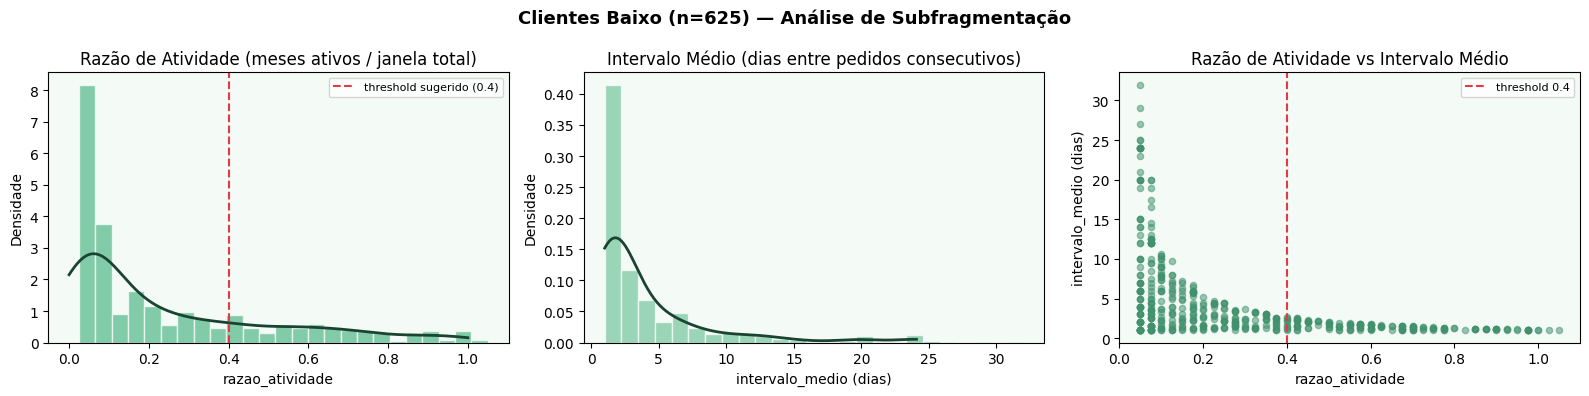

Percentis de razao_atividade:
  p10: 0.025
  p25: 0.050
  p33: 0.050
  p40: 0.075
  p50: 0.125
  p60: 0.200
  p75: 0.375


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Gráfico 1: distribuição de razao_atividade ---
data_ra = baixo["razao_atividade"].dropna()
axes[0].hist(data_ra, bins=25, color=VERDE[4], edgecolor="white", density=True, alpha=0.7)
kde = gaussian_kde(data_ra)
x = np.linspace(0, 1, 300)
axes[0].plot(x, kde(x), color=VERDE[7], linewidth=2)
axes[0].axvline(0.4, color="#e63946", lw=1.5, ls="--", label="threshold sugerido (0.4)")
axes[0].set_title("Razão de Atividade (meses ativos / janela total)")
axes[0].set_xlabel("razao_atividade")
axes[0].set_ylabel("Densidade")
axes[0].legend(fontsize=8)
axes[0].set_facecolor("#f4faf6")

# --- Gráfico 2: distribuição de intervalo_medio ---
data_iv = baixo["intervalo_medio"].dropna()
axes[1].hist(data_iv, bins=25, color=VERDE[3], edgecolor="white", density=True, alpha=0.7)
kde2 = gaussian_kde(data_iv)
x2 = np.linspace(data_iv.min(), data_iv.quantile(0.99), 300)
axes[1].plot(x2, kde2(x2), color=VERDE[7], linewidth=2)
axes[1].set_title("Intervalo Médio (dias entre pedidos consecutivos)")
axes[1].set_xlabel("intervalo_medio (dias)")
axes[1].set_ylabel("Densidade")
axes[1].set_facecolor("#f4faf6")

# --- Gráfico 3: scatter razao_atividade vs intervalo_medio ---
axes[2].scatter(
    baixo["razao_atividade"], baixo["intervalo_medio"],
    alpha=0.5, s=20, color=VERDE[5]
)
axes[2].axvline(0.4, color="#e63946", lw=1.5, ls="--", label="threshold 0.4")
axes[2].set_title("Razão de Atividade vs Intervalo Médio")
axes[2].set_xlabel("razao_atividade")
axes[2].set_ylabel("intervalo_medio (dias)")
axes[2].legend(fontsize=8)
axes[2].set_facecolor("#f4faf6")

plt.suptitle(f"Clientes Baixo (n={len(baixo)}) — Análise de Subfragmentação", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Percentis úteis para escolha do threshold
print("Percentis de razao_atividade:")
for p in [10, 25, 33, 40, 50, 60, 75]:
    print(f"  p{p:2d}: {data_ra.quantile(p/100):.3f}")

In [44]:

cliente_mes.to_parquet("../data/processed/cliente_mes.parquet", index=False)
cliente_fidelidade.to_parquet("../data/processed/cliente_fidelidade.parquet", index=False)

print("Salvo em data/processed/")
print(f"  cliente_mes        : {cliente_mes.shape}")
print(f"  cliente_fidelidade : {cliente_fidelidade.shape}")

Salvo em data/processed/
  cliente_mes        : (9980, 9)
  cliente_fidelidade : (765, 15)
